In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/data.csv")

In [6]:
print("Размер данных:", df.shape)

print("\nТипы данных:")
print(df.dtypes)

print("\nПропуски:")
print(df.isnull().sum())

print("\nДубликаты:", df.duplicated().sum())

Размер данных: (106, 10)

Типы данных:
Class         str
I0        float64
PA500     float64
HFS       float64
DA        float64
Area      float64
A.DA      float64
Max.IP    float64
DR        float64
P         float64
dtype: object

Пропуски:
Class     0
I0        0
PA500     0
HFS       0
DA        0
Area      0
A.DA      0
Max.IP    0
DR        0
P         0
dtype: int64

Дубликаты: 1


In [7]:
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Числовые признаки:")
print(list(numeric_columns))

print("\nКатегориальные признаки:")
print(list(categorical_columns))

Числовые признаки:
['I0', 'PA500', 'HFS', 'DA', 'Area', 'A.DA', 'Max.IP', 'DR', 'P']

Категориальные признаки:
['Class']


In [8]:
df[numeric_columns].describe()

,I0,PA500,HFS,DA,Area,A.DA,Max.IP,DR,P
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,784.251618,0.120133,0.114691,190.568642,7335.155162,23.473784,75.381258,166.710575,810.638127
std,753.950075,0.068596,0.101347,190.801448,18580.314213,23.354672,81.345838,181.309580,763.019135
min,103.000000,0.012392,-0.066323,19.647670,70.426239,1.595742,7.968783,-9.257696,124.978561
25%,250.000000,0.067413,0.043982,53.845470,409.647141,8.180321,26.893773,41.781258,270.215238
50%,384.936489,0.105418,0.086568,120.777303,2219.581163,16.133657,44.216040,97.832557,454.108153
75%,1487.989626,0.169602,0.166504,255.334809,7615.204968,30.953294,83.671755,232.990070,1301.559438
max,2800.000000,0.358316,0.467748,1063.441427,174480.476218,164.071543,436.099640,977.552367,2896.582483


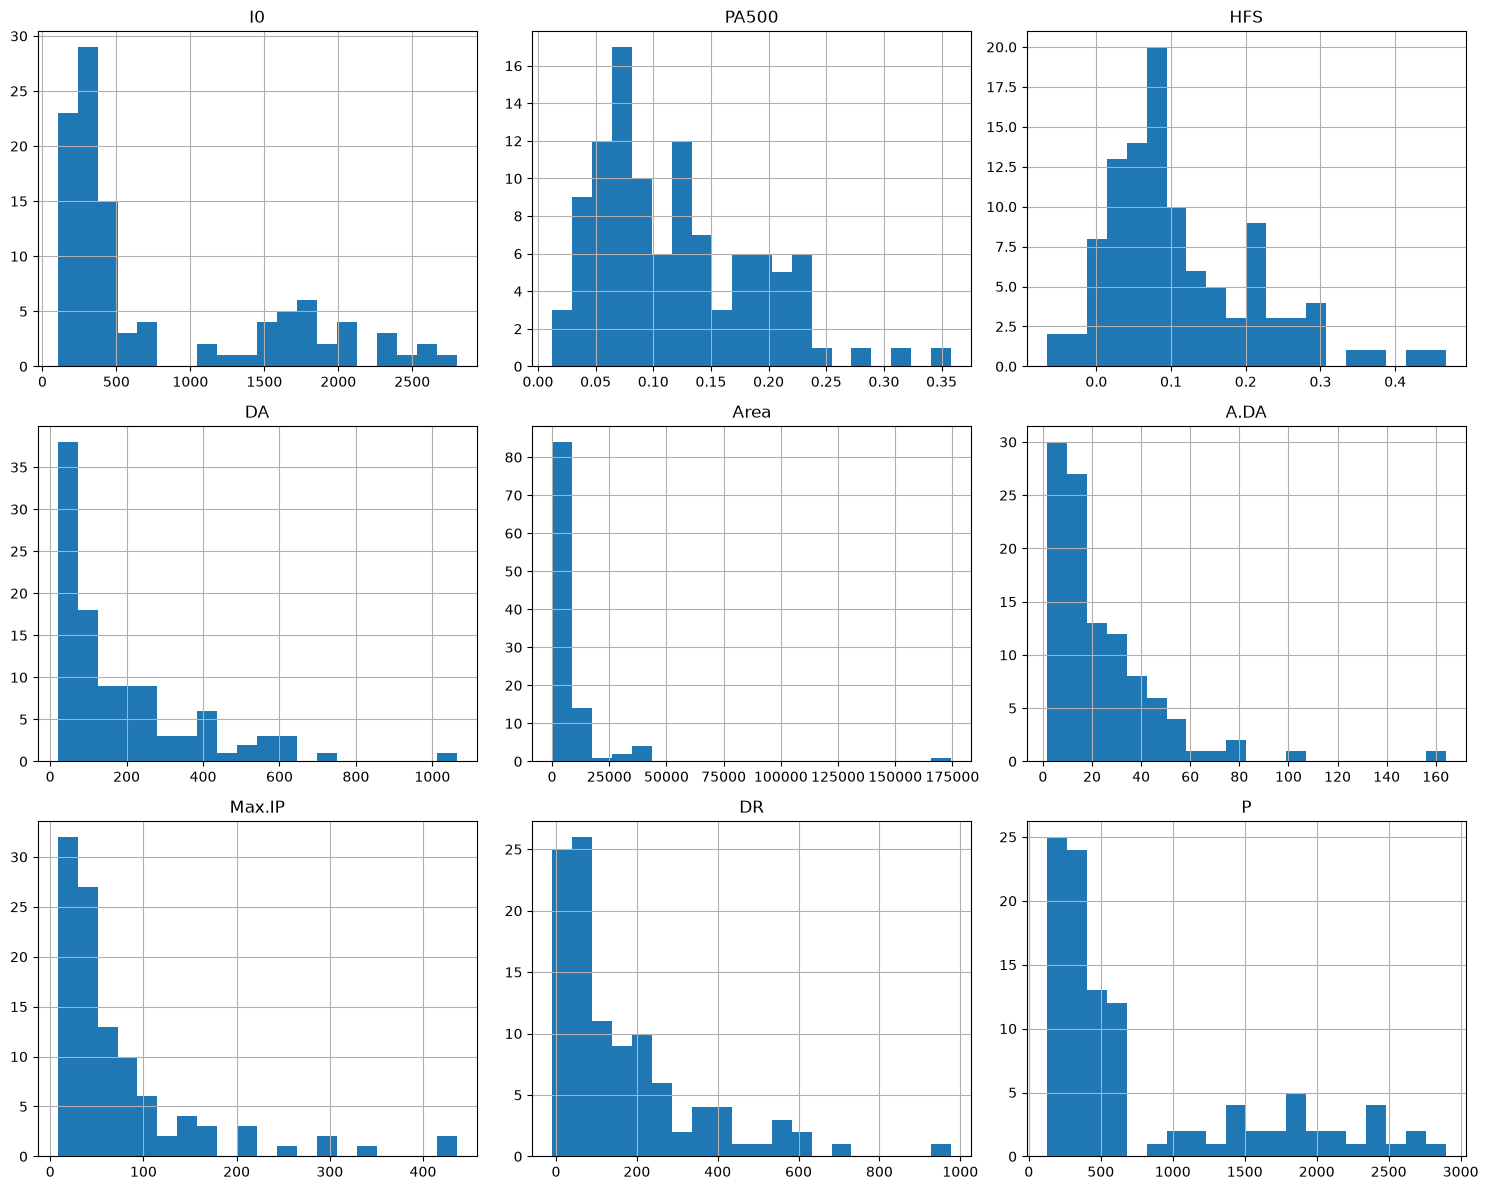

In [9]:
df[numeric_columns].hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

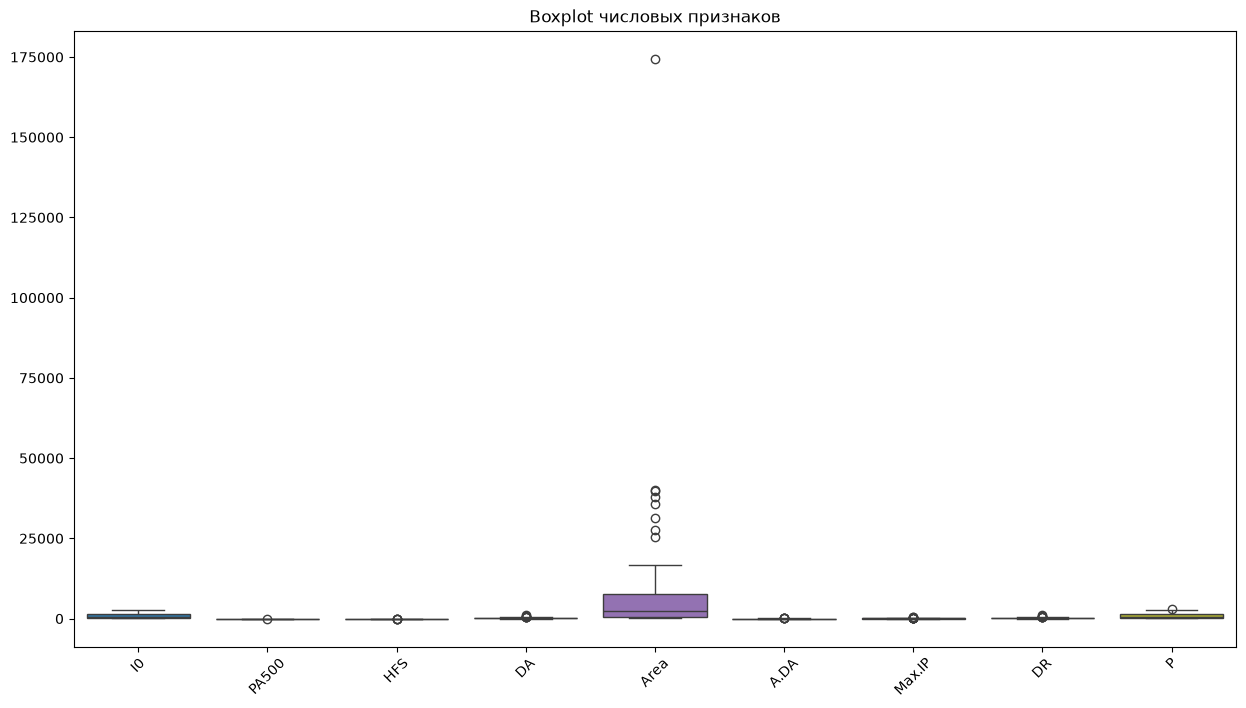

In [10]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_columns])
plt.xticks(rotation=45)
plt.title("Boxplot числовых признаков")
plt.show()

In [11]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Class
Class
adi    22
car    21
mas    18
gla    16
fad    15
con    14
Name: count, dtype: int64


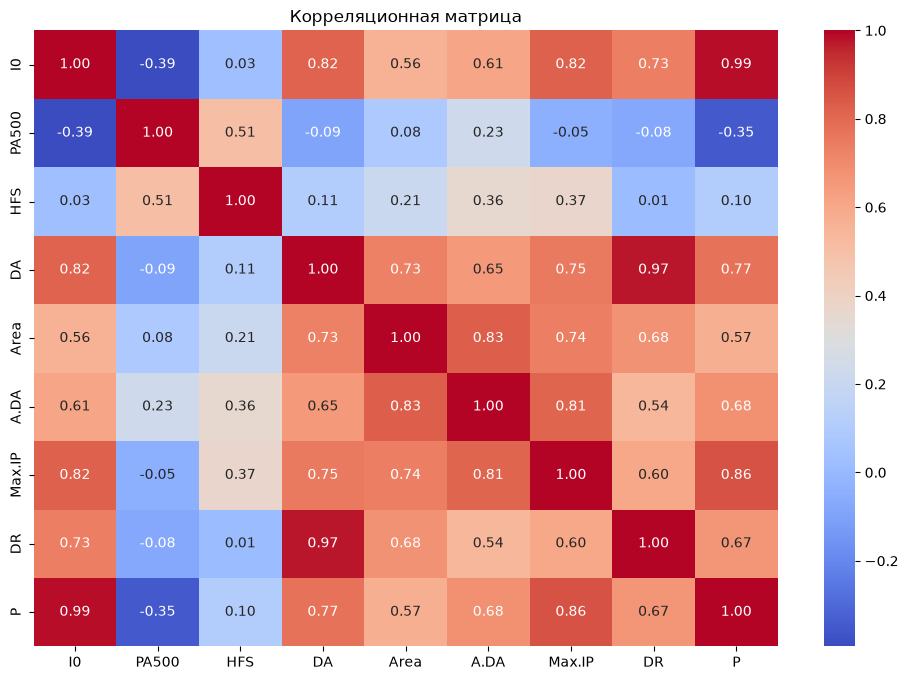

In [12]:
correlation = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

In [13]:
corr_pairs = correlation.unstack()

corr_pairs = corr_pairs[
    (corr_pairs != 1)
].sort_values(key=abs, ascending=False)

corr_pairs.head(10)

I0      P         0.988697
P       I0        0.988697
DA      DR        0.974202
DR      DA        0.974202
Max.IP  P         0.861837
P       Max.IP    0.861837
Area    A.DA      0.830172
A.DA    Area      0.830172
I0      Max.IP    0.823668
Max.IP  I0        0.823668
dtype: float64

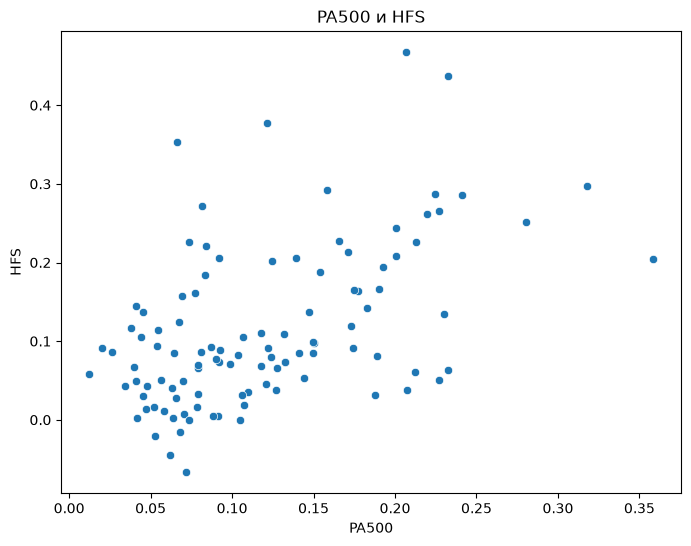

In [14]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="PA500",
    y="HFS"
)

plt.title("PA500 и HFS")
plt.show()

In [16]:
print(df["Class"].value_counts())

Class
adi    22
car    21
mas    18
gla    16
fad    15
con    14
Name: count, dtype: int64


In [17]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
adi    20.754717
car    19.811321
mas    16.981132
gla    15.094340
fad    14.150943
con    13.207547
Name: proportion, dtype: float64


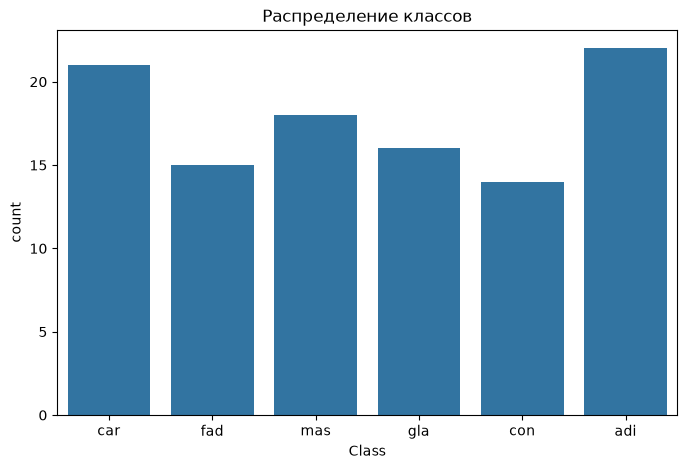

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Class")

plt.title("Распределение классов")
plt.show()

## Итоговый отчёт

1. Датасет содержит 107 строк и 9 признаков.

2. Были обнаружены пропущенные значения в признаках 0

3. В числовых признаках были обнаружены потенциальные выбросы. Наиболее выраженные выбросы наблюдаются в признаке Area, где несколько значений значительно превышают основной диапазон данных. Также отдельные потенциальные выбросы присутствуют в признаке P и некоторых других числовых признаках.

4. Распределение всех числовых признаков имеет правостороннюю асимметрию. Наиболее выраженная асимметрия наблюдается у признака Area (skewness = 7.27). Также заметная асимметрия присутствует у A.DA (2.83), Max.IP (2.48), DR (1.85) и DA (1.78). На следующем этапе необходимо рассмотреть методы обработки сильно асимметричных признаков

5. Корреляционный анализ показал наличие сильных положительных связей между рядом числовых признаков. Наиболее сильная корреляция наблюдается между I0 и P (r = 0.99), а также между DA и DR (r = 0.97). Также сильная связь наблюдается между Max.IP и P (r = 0.86). Для визуальной проверки этих зависимостей были построены диаграммы рассеяния.

6. Распределение целевой переменной Class показывает наличие небольшого дисбаланса между классами. Наиболее представлен класс adi — 22 объекта (20.8%), а наименее представлен класс con — 14 объектов (13.2%). При этом распределение классов относительно равномерное, поскольку доли классов находятся в диапазоне от 13.2% до 20.8%.

7. На следующем этапе планируется обработать пропуски и выбросы, а также подготовить признаки для дальнейшего построения ML-модели.

In [24]:
class_counts = df["Class"].value_counts()

print(class_counts)

Class
adi    22
car    21
mas    18
gla    16
fad    15
con    14
Name: count, dtype: int64


In [25]:
df["Class"].value_counts()

Class
adi    22
car    21
mas    18
gla    16
fad    15
con    14
Name: count, dtype: int64

In [26]:
df["Class"].value_counts(normalize=True).round(3) * 100

Class
adi    20.8
car    19.8
mas    17.0
gla    15.1
fad    14.2
con    13.2
Name: proportion, dtype: float64